In [86]:
import requests
import pandas as pd
import json
import sys

code_list = [944405, 57603, 944412]
sys.path.append('..')
df_count = pd.read_csv('dft_rawcount_local_authority_id_85.csv', low_memory=False)
df_count = df_count[df_count['direction_of_travel'].isin(['N', 'E'])]
df_count = df_count.drop(columns=[
    'region_id', 'region_name', 'local_authority_id', 'local_authority_name',
    'easting', 'northing',  # if using lat/lon
    'hgvs_2_rigid_axle', 'hgvs_3_rigid_axle', 'hgvs_4_or_more_rigid_axle',
    'hgvs_3_or_4_articulated_axle', 'hgvs_5_articulated_axle', 'hgvs_6_articulated_axle'
])
df_count = df_count[df_count['count_point_id'].isin(code_list)]
df_count = df_count[df_count['hour'].between(8,8)]
df_count = df_count[df_count['year'].between(2008, 2016)]
df_count

,count_point_id,direction_of_travel,year,count_date,hour,road_name,road_type,start_junction_road_name,end_junction_road_name,latitude,longitude,link_length_km,link_length_miles,pedal_cycles,two_wheeled_motor_vehicles,cars_and_taxis,buses_and_coaches,lgvs,all_hgvs,all_motor_vehicles
13980,57603,N,2008,2008-04-25,8,A6010,Major,B5093,B5117,53.451568,-2.222336,1.1,0.68,31,9,626,90,53,2,780
14003,57603,N,2016,2016-09-08,8,A6010,Major,B5093,B5117,53.451568,-2.222336,1.1,0.68,192,6,507,63,38,3,617
26225,944405,N,2009,2009-06-10,8,B5093,Minor,NaN,NaN,53.436662,-2.224170,NaN,NaN,10,5,572,184,23,10,794
26232,944405,N,2010,2010-06-09,8,B5093,Minor,NaN,NaN,53.436662,-2.224170,NaN,NaN,129,2,490,130,47,13,682
26262,944405,N,2011,2011-06-15,8,B5093,Minor,NaN,NaN,53.436662,-2.224170,NaN,NaN,89,6,427,69,48,8,558
26291,944405,N,2012,2012-06-13,8,B5093,Minor,NaN,NaN,53.436662,-2.224170,NaN,NaN,92,6,451,63,35,6,561
26306,944405,N,2013,2013-06-12,8,B5093,Minor,NaN,NaN,53.436662,-2.224170,NaN,NaN,84,3,406,61,51,7,528
26346,944405,N,2014,2014-06-11,8,B5093,Minor,NaN,NaN,53.436662,-2.224170,NaN,NaN,71,1,394,57,38,11,501
26365,944405,N,2016,2016-06-08,8,B5093,Minor,NaN,NaN,53.436662,-2.224170,NaN,NaN,75,3,282,76,31,5,397
27267,944412,E,2008,2008-04-15,8,B5117,Minor,NaN,NaN,53.453355,-2.223324,NaN,NaN,11,9,276,47,76,19,427


In [87]:
count1 = df_count[df_count['count_point_id'] == 944405]
avg1 = sum(count1['all_motor_vehicles'])/len(count1['all_motor_vehicles'])
free_speed = 40 #km/h
density1 = avg1/free_speed
print(density1)

14.360714285714286


In [88]:
def calculate_density_from_flow(countpointid, free_speed):
    count = df_count[df_count['count_point_id'] == countpointid]
    avg = sum(count['all_motor_vehicles'])/len(count['all_motor_vehicles'])
    density = avg/free_speed
    return [density, count['latitude'].values[0], count['longitude'].values[0]]
arr = []
for id, speed in zip(code_list, [48, 48, 30]):
    print(calculate_density_from_flow(id, speed))
    arr.append(calculate_density_from_flow(id, speed))

arr.append([6, 53.45927628199057, -2.2276463370981574])
arr.append([6, 53.4645870298434, -2.2320827813567172])### Guess for bus density on bus only road

[11.967261904761905, np.float64(53.43666163), np.float64(-2.22416998)]
[14.552083333333334, np.float64(53.45156846), np.float64(-2.22233599)]
[14.233333333333333, np.float64(53.45335535), np.float64(-2.2233241)]


In [89]:
def distance_lat_long(lat1, lon1, lat2, lon2):
    osrm_url = f"https://router.project-osrm.org/route/v1/driving/{lon1},{lat1};{lon2},{lat2}"
    params = {"overview": "full", "geometries": "geojson"}
    osrm_req = requests.get(osrm_url, params=params)
    osrm_data = osrm_req.json()
    route = osrm_data['routes'][0]
    distance = route['distance']
    return distance

In [90]:
dis1_2 = distance_lat_long(arr[0][1], arr[0][2], arr[1][1], arr[1][2])
dis2_3 = distance_lat_long(arr[1][1], arr[1][2], arr[2][1], arr[2][2])
dis3_4 = distance_lat_long(arr[2][1], arr[2][2], arr[3][1], arr[3][2])
dis4_5 = 650
print(dis1_2, dis2_3, dis3_4, dis4_5)
n1_2 = int(dis1_2/10) + 1
n2_3 = int(dis2_3/10)
n3_4 = int(dis3_4/10) + 1
n4_5 = int(dis4_5/10)
n= [n1_2, n2_3, n3_4, n4_5]

1849.5 210.5 722.8 650


In [91]:
density_arr = []
for i in range(len(arr)-1):
    if i != 2:
        delta_p = (arr[i+1][0] - arr[i][0])/n[i]
    if i == 3:
        delta_p = 0
    for j in range(n[i]):
        density_arr.append(arr[i][0] + delta_p*j)
print(density_arr)

[11.967261904761905, 11.981233912483912, 11.99520592020592, 12.009177927927928, 12.023149935649936, 12.037121943371943, 12.051093951093952, 12.065065958815959, 12.079037966537967, 12.093009974259974, 12.106981981981983, 12.12095398970399, 12.134925997425999, 12.148898005148006, 12.162870012870012, 12.176842020592021, 12.190814028314028, 12.204786036036037, 12.218758043758044, 12.232730051480052, 12.24670205920206, 12.260674066924068, 12.274646074646075, 12.288618082368084, 12.30259009009009, 12.316562097812097, 12.330534105534106, 12.344506113256113, 12.358478120978122, 12.372450128700129, 12.386422136422137, 12.400394144144144, 12.414366151866153, 12.42833815958816, 12.442310167310168, 12.456282175032175, 12.470254182754182, 12.48422619047619, 12.498198198198198, 12.512170205920206, 12.526142213642213, 12.540114221364222, 12.554086229086229, 12.568058236808238, 12.582030244530245, 12.596002252252253, 12.60997425997426, 12.623946267696269, 12.637918275418276, 12.651890283140283, 12.665

[13.47623873873874, 13.490210746460747, 13.504182754182754, 13.518154761904762, 13.53212676962677, 13.546098777348778, 13.560070785070785, 13.574042792792794, 13.5880148005148, 13.60198680823681, 13.615958815958816, 13.629930823680825, 13.643902831402832, 13.65787483912484, 13.671846846846847, 13.685818854568854, 13.699790862290863, 13.71376287001287, 13.727734877734878, 13.741706885456885, 13.755678893178894, 13.769650900900901, 13.78362290862291, 13.797594916344917, 13.811566924066925, 13.825538931788932, 13.83951093951094, 13.853482947232948, 13.867454954954955, 13.881426962676963, 13.89539897039897, 13.909370978120979, 13.923342985842986, 13.937314993564994, 13.951287001287001, 13.96525900900901, 13.979231016731017, 13.993203024453024, 14.007175032175033, 14.021147039897041, 14.035119047619048, 14.049091055341055, 14.063063063063064, 14.07703507078507, 14.09100707850708, 14.104979086229086, 14.118951093951095, 14.132923101673102, 14.14689510939511, 14.160867117117117, 14.1748391248

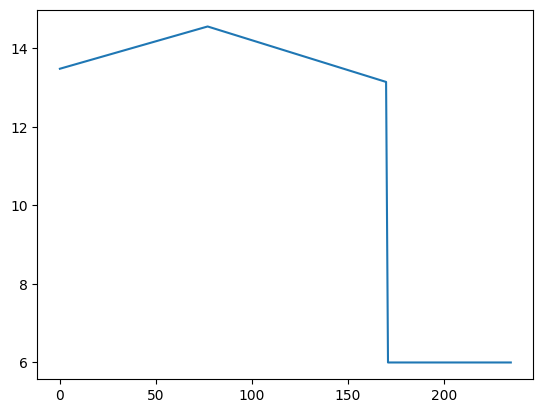

In [92]:
import matplotlib.pyplot as plt


n_start = int(distance_lat_long(arr[0][1], arr[0][2], 53.44537775031849, -2.2180905798922557)/10)
final_density = density_arr[n_start:]
plt.plot(range(len(final_density)), final_density)
print(final_density)